In [ ]:

# Bicanski 2026 - UCM: universal cognitive maps
# https://doi.org/10.1016/j.cub.2026.08.064
# correspondence: bicanski@cbs.mpg.de

In [1]:
# Architecture: a simple linear decoder

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid


In [2]:
# originally from 
# https://github.com/k-karna/VAEs
def show_images(images, title=None, nrow=8):

    grid = make_grid(images, nrow=nrow, padding=2, normalize=True)
    plt.figure(figsize=(10,10))
    plt.imshow(np.transpose(grid, (1,2,0))) #changing order of grid to (H, W, C)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

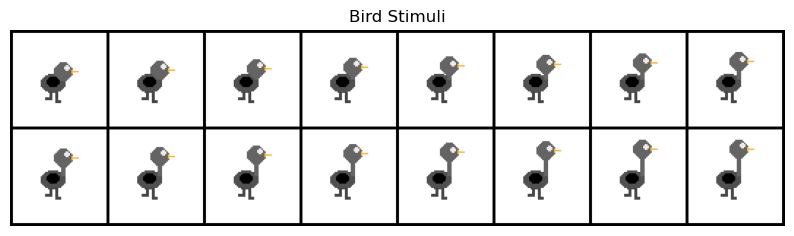

In [3]:
# Simple decoder toy model. Not meant to capture cortical preprocessing, just a symbolic step to 
# to highlight that prior to grid cells, the relevant dims need to be extracted from the stimuli
# we could have just used the neck and leg length ground truth values from the generation of the bird
# stimuli.

# Load / Prepare Bird Data - we generated them in the MakeBirds script

# Load bird dataset

#bird_images = torch.from_numpy(np.load("datasets/birds/bird_images_Nlarge.npy"))
#bird_leg_labels = torch.from_numpy(np.load("datasets/birds/bird_leg_labels_Nlarge.npy"))
#bird_neck_labels = torch.from_numpy(np.load("datasets/birds/bird_neck_labels_Nlarge.npy"))

bird_images = torch.from_numpy(np.load("datasets/birds/bird_images.npy"))
bird_leg_labels = torch.from_numpy(np.load("datasets/birds/bird_leg_labels.npy"))
bird_neck_labels = torch.from_numpy(np.load("datasets/birds/bird_neck_labels.npy"))


# Create train/test split (80/20)
n_samples = len(bird_images)
n_train = int(0.8 * n_samples)

X_train_bird = bird_images[:n_train]
y_train_leg = bird_leg_labels[:n_train]
y_train_neck = bird_neck_labels[:n_train]

X_test_bird = bird_images[n_train:]
y_test_leg = bird_leg_labels[n_train:]
y_test_neck = bird_neck_labels[n_train:]

# Wrap into DataLoader
train_loader = DataLoader(TensorDataset(X_train_bird, y_train_leg, y_train_neck), 
                batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_bird, y_test_leg, y_test_neck), 
                batch_size=16)

# Visualize some images
show_images(X_train_bird[:16], "Bird Stimuli")

In [4]:
# Specify Decoder

# Linear Decoder for Birds
class ModifiedLinearDecoder(nn.Module):
    def __init__(self, input_dim, num_leg_levels=10, num_neck_levels=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.leg_head = nn.Linear(input_dim, num_leg_levels)
        self.neck_head = nn.Linear(input_dim, num_neck_levels)

    def forward(self, x):
        x = self.flatten(x)
        leg_logits = self.leg_head(x)
        neck_logits = self.neck_head(x)
        return leg_logits, neck_logits

input_dim = 64 * 64 * 3  # bird images are 64x64 RGB

model = ModifiedLinearDecoder(input_dim=input_dim, num_leg_levels=16, num_neck_levels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [5]:

print(f"Unique leg labels in training: {len(np.unique(y_train_leg))}")
print(f"Unique neck labels in training: {len(np.unique(y_train_neck))}")

# Training Loop (same as above, just renamed variables)
num_epochs = 40

for epoch in range(1, num_epochs+1):
    model.train()
    total_loss = 0

    for X_batch, y_leg_batch, y_neck_batch in train_loader:
        optimizer.zero_grad()
        leg_logits, neck_logits = model(X_batch)

        loss_leg = criterion(leg_logits, y_leg_batch)
        loss_neck = criterion(neck_logits, y_neck_batch)
        loss = loss_leg + loss_neck
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch} | Loss: {total_loss / len(train_loader):.4f}")

Unique leg labels in training: 16
Unique neck labels in training: 16
Epoch 1 | Loss: 5.2004
Epoch 2 | Loss: 3.7324
Epoch 3 | Loss: 2.9328
Epoch 4 | Loss: 2.3134
Epoch 5 | Loss: 1.8679
Epoch 6 | Loss: 1.4876
Epoch 7 | Loss: 1.3467
Epoch 8 | Loss: 1.1013
Epoch 9 | Loss: 0.9715
Epoch 10 | Loss: 0.8324
Epoch 11 | Loss: 0.7187
Epoch 12 | Loss: 0.6359
Epoch 13 | Loss: 0.5880
Epoch 14 | Loss: 0.5140
Epoch 15 | Loss: 0.4585
Epoch 16 | Loss: 0.4095
Epoch 17 | Loss: 0.3828
Epoch 18 | Loss: 0.3543
Epoch 19 | Loss: 0.3167
Epoch 20 | Loss: 0.3040
Epoch 21 | Loss: 0.2603
Epoch 22 | Loss: 0.2558
Epoch 23 | Loss: 0.2323
Epoch 24 | Loss: 0.2167
Epoch 25 | Loss: 0.1949
Epoch 26 | Loss: 0.1849
Epoch 27 | Loss: 0.1726
Epoch 28 | Loss: 0.1656
Epoch 29 | Loss: 0.1597
Epoch 30 | Loss: 0.1454
Epoch 31 | Loss: 0.1351
Epoch 32 | Loss: 0.1285
Epoch 33 | Loss: 0.1213
Epoch 34 | Loss: 0.1170
Epoch 35 | Loss: 0.1110
Epoch 36 | Loss: 0.1051
Epoch 37 | Loss: 0.0995
Epoch 38 | Loss: 0.1024
Epoch 39 | Loss: 0.0892
Epoc

In [6]:
# Extract Predictions
model.eval()
with torch.no_grad():
    leg_preds = []
    neck_preds = []

    for X_batch, _, _ in test_loader:
        leg_logits, neck_logits = model(X_batch)
        leg_preds.append(leg_logits.argmax(dim=1))
        neck_preds.append(neck_logits.argmax(dim=1))

    leg_preds = torch.cat(leg_preds)
    neck_preds = torch.cat(neck_preds)

leg_preds_np = leg_preds.cpu().numpy()
neck_preds_np = neck_preds.cpu().numpy()
X_bird_np = X_train_bird.numpy()

# Save
#filename = "datasets/birds/bird_linear_dec_Nlarge.npz"
filename = "datasets/birds/bird_linear_dec.npz"
np.savez(filename, leg_preds_np=leg_preds_np, neck_preds_np=neck_preds_np, X_np=X_bird_np)

In [7]:
# more predictions

# train + test combined
model.eval()
with torch.no_grad():
    # Load ALL images
    #all_bird_images = torch.from_numpy(np.load("datasets/birds/bird_images_Nlarge.npy"))
    all_bird_images = torch.from_numpy(np.load("datasets/birds/bird_images.npy"))
    all_loader = DataLoader(all_bird_images, batch_size=16)
    
    leg_preds = []
    neck_preds = []

    for X_batch in all_loader:
        leg_logits, neck_logits = model(X_batch)
        leg_preds.append(leg_logits.argmax(dim=1))
        neck_preds.append(neck_logits.argmax(dim=1))

    leg_preds = torch.cat(leg_preds)
    neck_preds = torch.cat(neck_preds)

leg_preds_np = leg_preds.cpu().numpy()
neck_preds_np = neck_preds.cpu().numpy()
X_bird_np = all_bird_images.numpy()

# Save ALL predictions
#filename = "datasets/birds/bird_linear_dec_all_Nlarge.npz"
filename = "datasets/birds/bird_linear_dec_all.npz"

np.savez(filename, leg_preds_np=leg_preds_np, neck_preds_np=neck_preds_np, X_np=X_bird_np)

print(f"Saved predictions for all {len(leg_preds_np)} images")

Saved predictions for all 1280 images
